# 0823_kimjaehak_004_duplicate_groups

> EDA 001에서 확인한 완전 중복과 timestamp 그룹을 심층 분석합니다. 실제 행이나 불필요한 고유값은 출력하지 않고 집계 결과만 제시합니다.

## 분석 질문

1. `record_id` 제외 완전 중복은 어떤 크기·검사유형·라벨·시간 분포를 보이는가?
2. 같은 timestamp 내부 반복과 서로 다른 timestamp 사이의 입력 반복은 어떻게 다른가?
3. timestamp 그룹의 크기, 검사유형 수, mixed-label 구조는 어떠한가?
4. 시간·타깃을 제외한 입력 signature의 반복 및 label conflict는 어느 정도인가?
5. timestamp 경계를 보존한 시간순 60/20/20 분할에서 signature가 split 사이에 얼마나 재등장하는가?

## 1. 설정과 데이터 로딩

논문에 따르면 timestamp는 PCB가 AOI에 진입할 때 생성되어 한 PCB의 여러 납땜 지점이 공유할 수 있습니다. 다만 공개 CSV에는 원 로그 병합에 사용한 PCB+납땜 지점 고유 ID가 없으므로 timestamp는 완전한 PCB 식별자가 아니라 그룹 대리 변수로 해석합니다.

In [1]:
from pathlib import Path
import os
import platform

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data/raw/dataset.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("data/raw/dataset.csv를 찾을 수 없습니다. 저장소 루트에서 실행하세요.")

os.environ.setdefault("MPLCONFIGDIR", "/tmp/siemens_aoi_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

EXPERIMENT_ID = "0823_kimjaehak_004_duplicate_groups"
RANDOM_STATE = 42
DATA_PATH = REPO_ROOT / "data/raw/dataset.csv"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("experiment:", EXPERIMENT_ID)
print("python:", platform.python_version())
print("pandas:", pd.__version__)
print("data file exists:", DATA_PATH.exists())

experiment: 0823_kimjaehak_004_duplicate_groups
python: 3.12.13
pandas: 3.0.5
data file exists: True


In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = df.columns[0]
if source_index_column.startswith("Unnamed:"):
    df = df.rename(columns={source_index_column: "record_id"})
elif source_index_column != "record_id":
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

TARGET = "class"
TYPE_COLUMN = "inspection_type"
TIME_COLUMN = "timestamp"
OFFICIAL_COLUMNS = [column for column in df.columns if column != "record_id"]
INPUT_COLUMNS = [
    column for column in OFFICIAL_COLUMNS if column not in {TIME_COLUMN, TARGET}
]
parsed_timestamp = pd.to_datetime(df[TIME_COLUMN], errors="coerce", utc=True)
assert parsed_timestamp.notna().all(), "timestamp 변환 실패가 있습니다."

display(
    pd.Series(
        {
            "rows": len(df),
            "official_columns": len(OFFICIAL_COLUMNS),
            "input_signature_columns": len(INPUT_COLUMNS),
            "unique_timestamps": df[TIME_COLUMN].nunique(),
        },
        name="value",
    ).to_frame()
)

,value
rows,440274
official_columns,77
input_signature_columns,75
unique_timestamps,39742


## 2. 메모리 안전한 signature 정의와 한계

- **완전 중복 signature**: `record_id`를 제외한 공식 77개 컬럼(timestamp와 target 포함)
- **입력 signature**: `record_id`, timestamp, target을 제외한 75개 모델 입력 컬럼

원본 75~77개 컬럼을 문자열로 합치거나 Python tuple로 복제하지 않고 pandas의 64-bit 행 해시를 사용합니다. 완전 중복은 `DataFrame.duplicated`의 실제 컬럼 비교 결과와 해시 집계를 대조합니다. 입력 signature 집계는 64-bit 해시에 의존하므로 이론적인 해시 충돌 가능성이 있으며, 운영용 영구 키로 사용해서는 안 됩니다.

In [3]:
exact_hash = pd.util.hash_pandas_object(
    df[OFFICIAL_COLUMNS], index=False
).astype("uint64")
input_hash = pd.util.hash_pandas_object(
    df[INPUT_COLUMNS], index=False
).astype("uint64")

exact_sizes = exact_hash.value_counts(sort=False)
duplicate_exact_sizes = exact_sizes[exact_sizes > 1]
hash_exact_excess = int((duplicate_exact_sizes - 1).sum())
column_exact_excess = int(
    df.duplicated(subset=OFFICIAL_COLUMNS, keep="first").sum()
)
assert hash_exact_excess == column_exact_excess, (
    "완전 중복의 해시 집계와 실제 컬럼 비교가 다릅니다."
)

work = pd.DataFrame(
    {
        "exact_hash": exact_hash,
        "input_hash": input_hash,
        TIME_COLUMN: df[TIME_COLUMN],
        "parsed_timestamp": parsed_timestamp,
        "month": parsed_timestamp.dt.strftime("%Y-%m"),
        TARGET: df[TARGET],
        TYPE_COLUMN: df[TYPE_COLUMN],
    }
)
print("완전 중복 해시 집계와 실제 컬럼 비교 결과가 일치합니다.")

완전 중복 해시 집계와 실제 컬럼 비교 결과가 일치합니다.


## 3. `record_id` 제외 완전 중복

완전 중복은 timestamp와 label까지 같으므로 각 중복 그룹은 정의상 하나의 timestamp·검사유형·label에만 속합니다. 그룹 크기와 유형·라벨·월별 편중을 확인합니다.

In [4]:
exact_duplicate_mask = exact_hash.isin(duplicate_exact_sizes.index)
exact_duplicate_rows = work.loc[exact_duplicate_mask].copy()
exact_duplicate_rows["month"] = exact_duplicate_rows["parsed_timestamp"].dt.strftime("%Y-%m")

exact_summary = pd.Series(
    {
        "duplicate_groups": len(duplicate_exact_sizes),
        "rows_in_duplicate_groups": int(duplicate_exact_sizes.sum()),
        "duplicate_excess_rows": hash_exact_excess,
        "involved_rows_pct": exact_duplicate_mask.mean() * 100,
        "excess_rows_pct": hash_exact_excess / len(df) * 100,
        "median_group_size": float(duplicate_exact_sizes.median()),
        "p95_group_size": float(duplicate_exact_sizes.quantile(0.95)),
        "maximum_group_size": int(duplicate_exact_sizes.max()),
    },
    name="value",
)
display(exact_summary.to_frame())

def exact_breakdown(column):
    result = (
        exact_duplicate_rows.groupby(column, observed=True)
        .agg(rows=("exact_hash", "size"), groups=("exact_hash", "nunique"))
    )
    result["excess_rows"] = result["rows"] - result["groups"]
    result = result.join(work.groupby(column, observed=True).size().rename("all_rows"))
    result["involved_rows_pct"] = result["rows"] / result["all_rows"] * 100
    result["excess_rows_pct"] = result["excess_rows"] / result["all_rows"] * 100
    return result

exact_by_type = exact_breakdown(TYPE_COLUMN)
exact_by_label = exact_breakdown(TARGET)
exact_by_month = exact_breakdown("month")
display(exact_by_type)
display(exact_by_label)
display(exact_by_month)

,value
duplicate_groups,"4,250.0000"
rows_in_duplicate_groups,"13,002.0000"
duplicate_excess_rows,"8,752.0000"
involved_rows_pct,2.9532
excess_rows_pct,1.9879
median_group_size,2.0000
p95_group_size,9.0000
maximum_group_size,17.0000


,rows,groups,excess_rows,all_rows,involved_rows_pct,excess_rows_pct
inspection_type,,,,,,
0,8642,2347,6295,97053,8.9044,6.4861
1,16,8,8,57673,0.0277,0.0139
2,3656,1571,2085,128174,2.8524,1.6267
3,688,324,364,151931,0.4528,0.2396


,rows,groups,excess_rows,all_rows,involved_rows_pct,excess_rows_pct
class,,,,,,
0,12857,4206,8651,435652,2.9512,1.9858
1,145,44,101,4622,3.1372,2.1852


,rows,groups,excess_rows,all_rows,involved_rows_pct,excess_rows_pct
month,,,,,,
1970-06,254,114,140,17105,1.4849,0.8185
1970-07,557,239,318,60372,0.9226,0.5267
1970-08,7204,1717,5487,108371,6.6475,5.0632
1970-09,2396,1034,1362,116782,2.0517,1.1663
1970-10,2585,1143,1442,136436,1.8947,1.0569
1970-11,6,3,3,1208,0.4967,0.2483


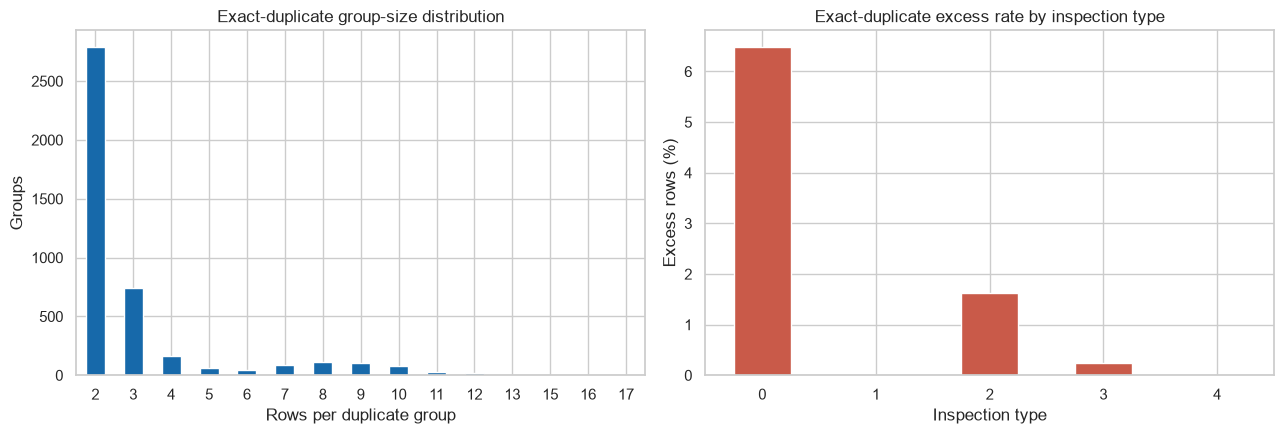

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

duplicate_exact_sizes.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#1769aa"
)
axes[0].set_title("Exact-duplicate group-size distribution")
axes[0].set_xlabel("Rows per duplicate group")
axes[0].set_ylabel("Groups")
axes[0].tick_params(axis="x", rotation=0)

exact_by_type["excess_rows_pct"].reindex(range(5), fill_value=0).plot(
    kind="bar", ax=axes[1], color="#c95a49"
)
axes[1].set_title("Exact-duplicate excess rate by inspection type")
axes[1].set_xlabel("Inspection type")
axes[1].set_ylabel("Excess rows (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. 같은 timestamp 내부와 서로 다른 timestamp 사이의 입력 반복

완전 중복은 timestamp를 포함하므로 다른 timestamp로 넘어갈 수 없습니다. 따라서 시간 간 반복은 timestamp와 target을 제외한 **입력 signature**로 비교합니다. 동일 입력이 같은 timestamp 안에서 반복될 수 있고, 여러 timestamp에 재등장할 수도 있습니다.

In [6]:
signature_groups = (
    work.groupby("input_hash", sort=False)
    .agg(
        rows=("input_hash", "size"),
        timestamps=(TIME_COLUMN, "nunique"),
        labels=(TARGET, "nunique"),
        inspection_types=(TYPE_COLUMN, "nunique"),
        first_timestamp=("parsed_timestamp", "min"),
        last_timestamp=("parsed_timestamp", "max"),
    )
)
repeated_signatures = signature_groups.loc[signature_groups["rows"] > 1]
within_only = repeated_signatures.loc[repeated_signatures["timestamps"] == 1]
across_timestamps = repeated_signatures.loc[repeated_signatures["timestamps"] > 1]

timestamp_signature_pairs = (
    work.groupby([TIME_COLUMN, "input_hash"], sort=False)
    .agg(rows=("input_hash", "size"), labels=(TARGET, "nunique"))
)
repeated_timestamp_pairs = timestamp_signature_pairs.loc[
    timestamp_signature_pairs["rows"] > 1
]

repeat_comparison = pd.DataFrame(
    [
        {
            "scope": "exact duplicate (timestamp+target included)",
            "groups": len(duplicate_exact_sizes),
            "rows": int(duplicate_exact_sizes.sum()),
            "excess_rows": int((duplicate_exact_sizes - 1).sum()),
            "label_conflict_groups": 0,
        },
        {
            "scope": "input signature repeated within a timestamp",
            "groups": len(repeated_timestamp_pairs),
            "rows": int(repeated_timestamp_pairs["rows"].sum()),
            "excess_rows": int((repeated_timestamp_pairs["rows"] - 1).sum()),
            "label_conflict_groups": int((repeated_timestamp_pairs["labels"] > 1).sum()),
        },
        {
            "scope": "input signature repeated at one timestamp only",
            "groups": len(within_only),
            "rows": int(within_only["rows"].sum()),
            "excess_rows": int((within_only["rows"] - 1).sum()),
            "label_conflict_groups": int((within_only["labels"] > 1).sum()),
        },
        {
            "scope": "input signature repeated across timestamps",
            "groups": len(across_timestamps),
            "rows": int(across_timestamps["rows"].sum()),
            "excess_rows": int((across_timestamps["rows"] - 1).sum()),
            "label_conflict_groups": int((across_timestamps["labels"] > 1).sum()),
        },
    ]
).set_index("scope")
display(repeat_comparison)

signature_summary = pd.Series(
    {
        "unique_input_signatures": len(signature_groups),
        "repeated_signature_groups": len(repeated_signatures),
        "rows_in_repeated_signatures": int(repeated_signatures["rows"].sum()),
        "repeated_signature_excess_rows": int((repeated_signatures["rows"] - 1).sum()),
        "maximum_signature_rows": int(repeated_signatures["rows"].max()),
        "maximum_timestamps_per_signature": int(repeated_signatures["timestamps"].max()),
        "signature_label_conflict_groups": int((signature_groups["labels"] > 1).sum()),
        "rows_in_conflicting_signatures": int(
            signature_groups.loc[signature_groups["labels"] > 1, "rows"].sum()
        ),
    },
    name="value",
)
display(signature_summary.to_frame())

,groups,rows,excess_rows,label_conflict_groups
scope,,,,
exact duplicate (timestamp+target included),4250,13002,8752,0
input signature repeated within a timestamp,4259,13025,8766,14
input signature repeated at one timestamp only,283,644,361,0
input signature repeated across timestamps,10175,58166,47991,70


,value
unique_input_signatures,391922
repeated_signature_groups,10458
rows_in_repeated_signatures,58810
repeated_signature_excess_rows,48352
maximum_signature_rows,5546
maximum_timestamps_per_signature,1638
signature_label_conflict_groups,70
rows_in_conflicting_signatures,14037


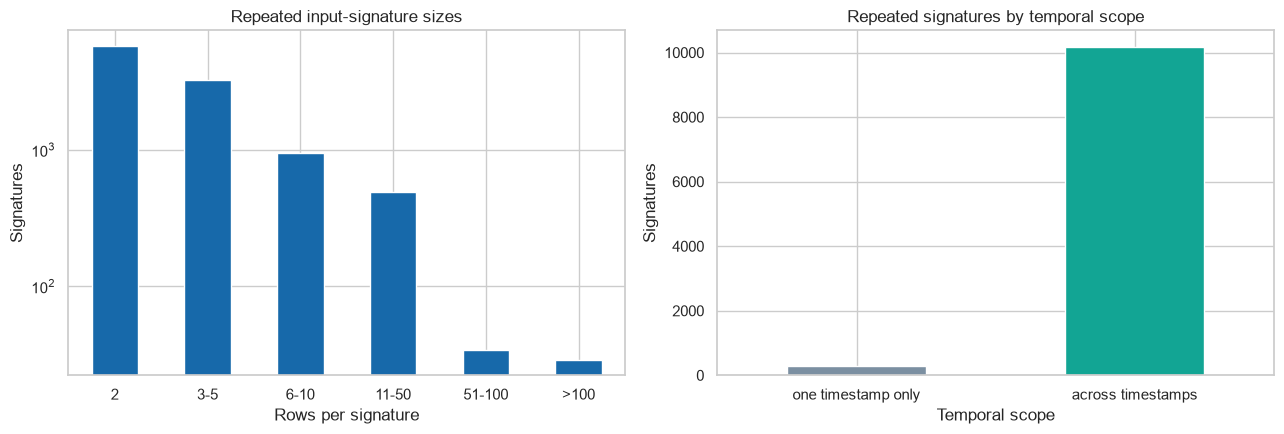

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

size_bins = pd.cut(
    repeated_signatures["rows"],
    bins=[1, 2, 5, 10, 50, 100, np.inf],
    labels=["2", "3-5", "6-10", "11-50", "51-100", ">100"],
    right=True,
)
size_bins.value_counts(sort=False).plot(kind="bar", ax=axes[0], color="#1769aa")
axes[0].set_title("Repeated input-signature sizes")
axes[0].set_xlabel("Rows per signature")
axes[0].set_ylabel("Signatures")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=0)

pd.Series(
    {
        "one timestamp only": len(within_only),
        "across timestamps": len(across_timestamps),
    }
).plot(kind="bar", ax=axes[1], color=["#7b8fa1", "#12a594"])
axes[1].set_title("Repeated signatures by temporal scope")
axes[1].set_xlabel("Temporal scope")
axes[1].set_ylabel("Signatures")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. timestamp 그룹 구조

같은 timestamp 그룹이 행 단위 무작위 분할로 흩어지면 같은 PCB일 가능성이 있는 지점들이 train과 validation/test에 동시에 들어갈 수 있습니다. 그룹 크기, 포함 검사유형 수, mixed-label 여부를 집계합니다.

In [8]:
timestamp_groups = (
    work.groupby(TIME_COLUMN, sort=False)
    .agg(
        rows=(TIME_COLUMN, "size"),
        inspection_types=(TYPE_COLUMN, "nunique"),
        labels=(TARGET, "nunique"),
        true_defects=(TARGET, "sum"),
        parsed_timestamp=("parsed_timestamp", "first"),
    )
)
mixed_label_timestamp_groups = timestamp_groups.loc[timestamp_groups["labels"] > 1]

timestamp_summary = pd.Series(
    {
        "timestamp_groups": len(timestamp_groups),
        "groups_with_multiple_rows": int((timestamp_groups["rows"] > 1).sum()),
        "groups_with_multiple_inspection_types": int(
            (timestamp_groups["inspection_types"] > 1).sum()
        ),
        "mixed_label_groups": len(mixed_label_timestamp_groups),
        "rows_in_mixed_label_groups": int(mixed_label_timestamp_groups["rows"].sum()),
        "median_rows_per_timestamp": float(timestamp_groups["rows"].median()),
        "p95_rows_per_timestamp": float(timestamp_groups["rows"].quantile(0.95)),
        "maximum_rows_per_timestamp": int(timestamp_groups["rows"].max()),
        "maximum_inspection_types_per_timestamp": int(
            timestamp_groups["inspection_types"].max()
        ),
    },
    name="value",
)
display(timestamp_summary.to_frame())

timestamp_type_count_distribution = (
    timestamp_groups["inspection_types"]
    .value_counts()
    .sort_index()
    .rename_axis("inspection_types_in_group")
    .to_frame("timestamp_groups")
)
timestamp_type_count_distribution["ratio_pct"] = (
    timestamp_type_count_distribution["timestamp_groups"] / len(timestamp_groups) * 100
)
display(timestamp_type_count_distribution)
display(
    timestamp_groups["rows"]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .rename("rows_per_timestamp")
    .to_frame()
)

,value
timestamp_groups,"39,742.0000"
groups_with_multiple_rows,"33,902.0000"
groups_with_multiple_inspection_types,"27,322.0000"
mixed_label_groups,715.0000
rows_in_mixed_label_groups,"11,588.0000"
median_rows_per_timestamp,6.0000
p95_rows_per_timestamp,36.9500
maximum_rows_per_timestamp,557.0000
maximum_inspection_types_per_timestamp,5.0000


,timestamp_groups,ratio_pct
inspection_types_in_group,,
1,12420,31.2516
2,12685,31.9184
3,7481,18.8239
4,6082,15.3037
5,1074,2.7024


,rows_per_timestamp
count,"39,742.0000"
mean,11.0783
std,16.1136
min,1.0000
50%,6.0000
75%,15.0000
90%,24.0000
95%,36.9500
99%,69.0000
max,557.0000


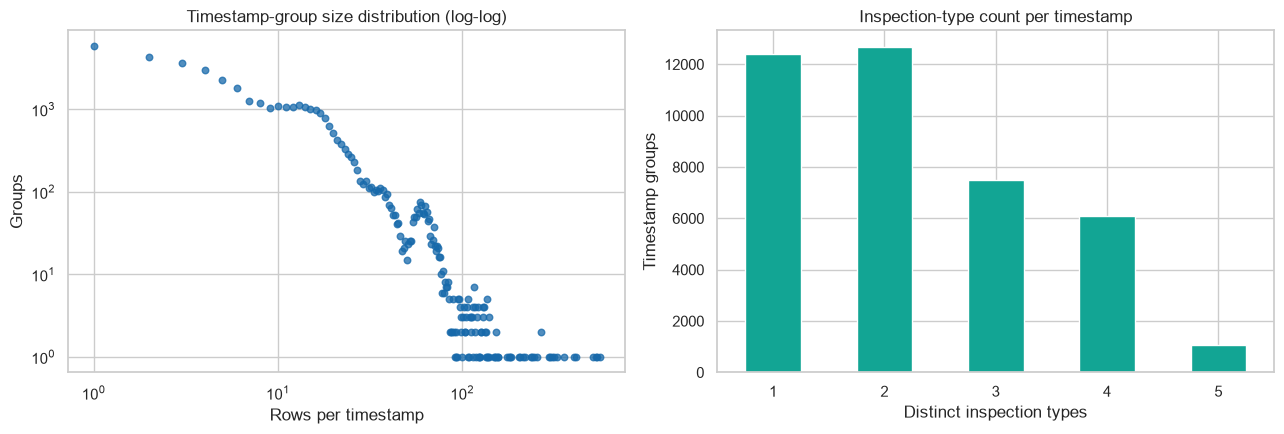

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

timestamp_size_frequency = timestamp_groups["rows"].value_counts().sort_index()
axes[0].scatter(
    timestamp_size_frequency.index,
    timestamp_size_frequency.values,
    color="#1769aa",
    alpha=0.75,
    s=22,
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Timestamp-group size distribution (log-log)")
axes[0].set_xlabel("Rows per timestamp")
axes[0].set_ylabel("Groups")

timestamp_type_count_distribution["timestamp_groups"].plot(
    kind="bar", ax=axes[1], color="#12a594"
)
axes[1].set_title("Inspection-type count per timestamp")
axes[1].set_xlabel("Distinct inspection types")
axes[1].set_ylabel("Timestamp groups")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 6. timestamp 경계를 보존한 시간순 60/20/20 분할

timestamp를 오름차순으로 정렬한 뒤 누적 행 수가 전체의 60%, 80%에 처음 도달하는 timestamp 그룹까지 각각 train과 validation에 포함합니다. 따라서 목표 비율과 몇 행 차이가 날 수 있지만 어느 timestamp도 둘 이상의 split에 섞이지 않습니다. 랜덤 시드는 재현성 표준값으로 명시하지만 이 결정론적 시간 분할에는 사용하지 않습니다.

In [10]:
sorted_timestamp_groups = timestamp_groups.sort_values("parsed_timestamp")
cumulative_rows = sorted_timestamp_groups["rows"].cumsum().to_numpy()
train_end_index = int(np.searchsorted(cumulative_rows, 0.60 * len(df), side="left"))
valid_end_index = int(np.searchsorted(cumulative_rows, 0.80 * len(df), side="left"))
ordered_timestamps = sorted_timestamp_groups.index.to_numpy()

timestamp_to_split = pd.Series(index=ordered_timestamps, dtype="object")
timestamp_to_split.iloc[: train_end_index + 1] = "train"
timestamp_to_split.iloc[train_end_index + 1 : valid_end_index + 1] = "valid"
timestamp_to_split.iloc[valid_end_index + 1 :] = "test"
split = df[TIME_COLUMN].map(timestamp_to_split)
assert split.notna().all()
assert pd.DataFrame({TIME_COLUMN: df[TIME_COLUMN], "split": split}).groupby(
    TIME_COLUMN
)["split"].nunique().max() == 1

split_summary = (
    pd.DataFrame(
        {
            "split": split,
            TIME_COLUMN: df[TIME_COLUMN],
            "parsed_timestamp": parsed_timestamp,
            TARGET: df[TARGET],
        }
    )
    .groupby("split", observed=True)
    .agg(
        rows=(TARGET, "size"),
        timestamp_groups=(TIME_COLUMN, "nunique"),
        true_defects=(TARGET, "sum"),
        defect_rate=(TARGET, "mean"),
        start=("parsed_timestamp", "min"),
        end=("parsed_timestamp", "max"),
    )
    .reindex(["train", "valid", "test"])
)
split_summary["row_ratio_pct"] = split_summary["rows"] / len(df) * 100
split_summary["defect_rate_pct"] = split_summary["defect_rate"] * 100
display(
    split_summary[
        ["rows", "row_ratio_pct", "timestamp_groups", "true_defects", "defect_rate_pct", "start", "end"]
    ]
)

,rows,row_ratio_pct,timestamp_groups,true_defects,defect_rate_pct,start,end
split,,,,,,,
train,264343,60.0406,26063,1901,0.7191,1970-06-23 03:58:55+00:00,1970-09-28 05:10:37+00:00
valid,87879,19.9601,6586,396,0.4506,1970-09-28 05:11:13+00:00,1970-10-13 16:54:14+00:00
test,88052,19.9994,7093,2325,2.6405,1970-10-13 16:54:52+00:00,1970-11-02 14:21:28+00:00


## 7. split 사이 입력 signature 재등장

동일 입력 signature가 이후 기간에 재등장하면 모델이 동일한 75개 입력값을 다시 보게 됩니다. 이는 실제 운영의 반복 패턴일 수도 있지만, 무작위 행 분할에서는 성능을 과대평가할 잠재 누수 요인이 됩니다. 아래에서는 시간순 분할을 유지한 채 pairwise 교집합, 이후 split에서 과거에 본 signature 행 비율, cross-split label conflict를 집계합니다.

In [11]:
split_signatures = pd.DataFrame(
    {"input_hash": input_hash, "split": split, TARGET: df[TARGET]}
)
signature_split_counts = (
    split_signatures.drop_duplicates(["input_hash", "split"])
    .groupby("input_hash", sort=False)["split"]
    .nunique()
)
cross_split_signatures = signature_split_counts.loc[signature_split_counts > 1]
signature_sets = {
    name: set(split_signatures.loc[split == name, "input_hash"].unique())
    for name in ["train", "valid", "test"]
}

pairwise_overlap_rows = []
for earlier, later in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    overlap = signature_sets[earlier] & signature_sets[later]
    later_mask = split == later
    pairwise_overlap_rows.append(
        {
            "split_pair": f"{earlier} -> {later}",
            "shared_signatures": len(overlap),
            "later_rows_with_shared_signature": int(
                input_hash.loc[later_mask].isin(overlap).sum()
            ),
            "later_rows_pct": float(input_hash.loc[later_mask].isin(overlap).mean() * 100),
        }
    )
pairwise_overlap = pd.DataFrame(pairwise_overlap_rows).set_index("split_pair")
display(pairwise_overlap)

valid_seen_before = input_hash.loc[split == "valid"].isin(signature_sets["train"])
test_seen_before = input_hash.loc[split == "test"].isin(
    signature_sets["train"] | signature_sets["valid"]
)
cross_split_group_details = (
    split_signatures.loc[
        split_signatures["input_hash"].isin(cross_split_signatures.index)
    ]
    .groupby("input_hash", sort=False)
    .agg(rows=(TARGET, "size"), labels=(TARGET, "nunique"))
)

cross_split_summary = pd.Series(
    {
        "cross_split_signature_groups": len(cross_split_signatures),
        "cross_split_signatures_pct_of_unique": len(cross_split_signatures) / len(signature_groups) * 100,
        "rows_in_cross_split_signatures": int(
            input_hash.isin(cross_split_signatures.index).sum()
        ),
        "valid_rows_seen_in_train": int(valid_seen_before.sum()),
        "valid_rows_seen_in_train_pct": float(valid_seen_before.mean() * 100),
        "test_rows_seen_in_train_or_valid": int(test_seen_before.sum()),
        "test_rows_seen_in_train_or_valid_pct": float(test_seen_before.mean() * 100),
        "later_rows_seen_before_total": int(valid_seen_before.sum() + test_seen_before.sum()),
        "later_rows_seen_before_pct": float(
            (valid_seen_before.sum() + test_seen_before.sum())
            / ((split != "train").sum())
            * 100
        ),
        "cross_split_label_conflict_groups": int(
            (cross_split_group_details["labels"] > 1).sum()
        ),
    },
    name="value",
)
display(cross_split_summary.to_frame())

,shared_signatures,later_rows_with_shared_signature,later_rows_pct
split_pair,,,
train -> valid,900,4268,4.8567
train -> test,846,5081,5.7705
valid -> test,1418,6324,7.1821


,value
cross_split_signature_groups,"2,948.0000"
cross_split_signatures_pct_of_unique,0.7522
rows_in_cross_split_signatures,"30,455.0000"
valid_rows_seen_in_train,"4,268.0000"
valid_rows_seen_in_train_pct,4.8567
test_rows_seen_in_train_or_valid,"8,515.0000"
test_rows_seen_in_train_or_valid_pct,9.6704
later_rows_seen_before_total,"12,783.0000"
later_rows_seen_before_pct,7.2659
cross_split_label_conflict_groups,43.0000


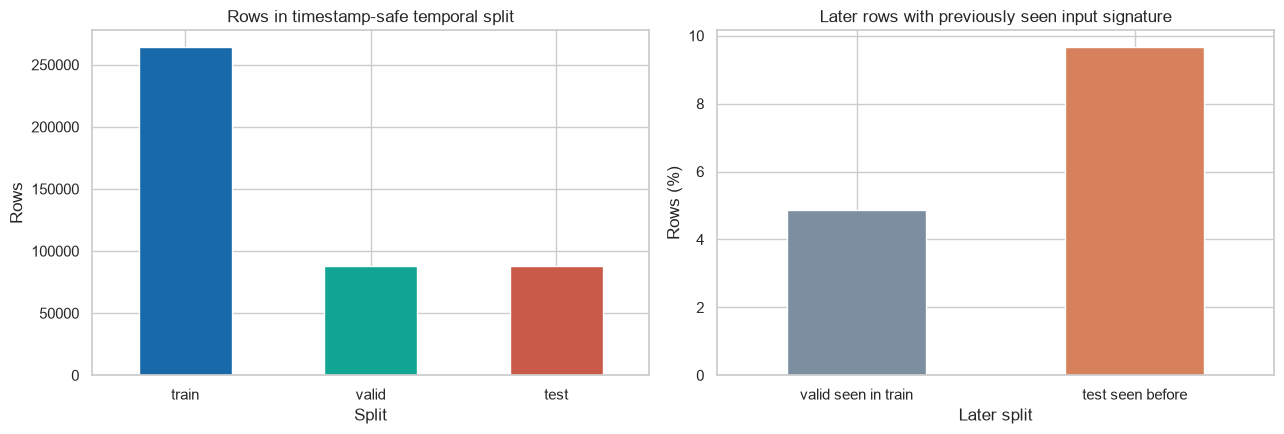

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

split_summary["rows"].plot(kind="bar", ax=axes[0], color=["#1769aa", "#12a594", "#c95a49"])
axes[0].set_title("Rows in timestamp-safe temporal split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=0)

pd.Series(
    {
        "valid seen in train": valid_seen_before.mean() * 100,
        "test seen before": test_seen_before.mean() * 100,
    }
).plot(kind="bar", ax=axes[1], color=["#7b8fa1", "#d6815b"])
axes[1].set_title("Later rows with previously seen input signature")
axes[1].set_xlabel("Later split")
axes[1].set_ylabel("Rows (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. 해석 한계

- timestamp는 논문이 제시한 그룹 단서지만 PCB 고유 ID는 아니므로 서로 다른 PCB가 우연히 같은 timestamp를 가질 가능성을 배제할 수 없습니다.
- 동일 입력 signature는 익명화·스케일링·기본 채움값 때문에 서로 다른 물리적 상황이 같은 벡터로 보이는 경우를 포함할 수 있습니다.
- label conflict는 라벨 노이즈의 정황이지만, 동일 signature가 동일 실물·동일 검사 사건이라는 증거는 아닙니다.
- 입력 signature는 pandas 64-bit 해시로 집계했습니다. 해시 충돌 가능성은 매우 낮지만 0은 아니며, 운영 식별자나 데이터 삭제 키로 사용하지 않습니다.
- 시간순 split 간 signature 재등장은 실제 운영 반복을 반영할 수도 있으므로 곧바로 제거하지 않고 seen/unseen 성능을 분리해 보고합니다.

## 9. 결론 및 다음 단계

아래 결론은 위 집계를 사용해 자동 생성합니다.

In [13]:
conclusion = f"""
### 핵심 결과

- 완전 중복은 **{len(duplicate_exact_sizes):,}개 그룹, {int(duplicate_exact_sizes.sum()):,}행**이며 초과 행은 **{hash_exact_excess:,}건 ({hash_exact_excess / len(df) * 100:.2f}%)**입니다. 그룹 중앙값은 {duplicate_exact_sizes.median():.0f}행, 최댓값은 {int(duplicate_exact_sizes.max()):,}행입니다.
- 입력 signature 반복은 **{len(repeated_signatures):,}개 그룹, {int(repeated_signatures['rows'].sum()):,}행**입니다. 이 중 **{len(across_timestamps):,}개 그룹**이 둘 이상의 timestamp에 걸쳐 재등장합니다.
- 입력은 같지만 label이 충돌하는 signature는 **{int((signature_groups['labels'] > 1).sum()):,}개**이며, 단순 중복 제거로 label noise를 해결할 수 없습니다.
- timestamp 그룹은 **{len(timestamp_groups):,}개**, 중앙값 {timestamp_groups['rows'].median():.0f}행, 최댓값 {int(timestamp_groups['rows'].max()):,}행입니다. mixed-label 그룹은 **{len(mixed_label_timestamp_groups):,}개**입니다.
- timestamp 경계를 보존한 시간순 분할에서 validation의 **{valid_seen_before.mean() * 100:.2f}%**, test의 **{test_seen_before.mean() * 100:.2f}%** 행은 이전 split에서 본 입력 signature를 가집니다.

### 권고

1. **기본 분할은 timestamp 그룹을 보존한 시간순 split**으로 구성합니다. 행 단위 무작위 분할은 사용하지 않습니다.
2. 완전 중복은 원인이 확인되지 않았으므로 원본에서 삭제하지 않습니다. 학습 단계에서만 `중복 유지`, `그룹별 1행`, `그룹 역빈도 sample weight`를 민감도 분석으로 비교합니다. validation/test는 현실 빈도를 보존합니다.
3. 주 평가를 전체 성능과 함께 `과거에 본 signature`/`처음 보는 signature`로 나누어 보고합니다. 재등장 signature를 제거한 보조 평가도 함께 제시합니다.
4. label-conflict signature는 강제 다수결로 덮어쓰지 않고 별도 플래그로 추적합니다. 모델 오류 분석에서 작업자 라벨 노이즈와 익명화 충돌 가능성을 함께 검토합니다.
5. timestamp와 입력 signature 어느 것도 PCB 고유 ID가 아니므로, 향후 원 제공처에서 비식별 PCB 그룹 ID를 받을 수 있다면 그 ID를 우선 사용합니다.

### 다음 실험

- 시간순 timestamp-group split을 공통 평가 프로토콜로 확정하고 split별 검사유형·피처 drift를 점검합니다.
- baseline 모델에서 중복 처리 세 전략과 seen/unseen signature 성능을 비교합니다.
- label-conflict signature에 대한 오류율과 예측 불확실성을 별도 분석합니다.
"""
display(Markdown(conclusion))


### 핵심 결과

- 완전 중복은 **4,250개 그룹, 13,002행**이며 초과 행은 **8,752건 (1.99%)**입니다. 그룹 중앙값은 2행, 최댓값은 17행입니다.
- 입력 signature 반복은 **10,458개 그룹, 58,810행**입니다. 이 중 **10,175개 그룹**이 둘 이상의 timestamp에 걸쳐 재등장합니다.
- 입력은 같지만 label이 충돌하는 signature는 **70개**이며, 단순 중복 제거로 label noise를 해결할 수 없습니다.
- timestamp 그룹은 **39,742개**, 중앙값 6행, 최댓값 557행입니다. mixed-label 그룹은 **715개**입니다.
- timestamp 경계를 보존한 시간순 분할에서 validation의 **4.86%**, test의 **9.67%** 행은 이전 split에서 본 입력 signature를 가집니다.

### 권고

1. **기본 분할은 timestamp 그룹을 보존한 시간순 split**으로 구성합니다. 행 단위 무작위 분할은 사용하지 않습니다.
2. 완전 중복은 원인이 확인되지 않았으므로 원본에서 삭제하지 않습니다. 학습 단계에서만 `중복 유지`, `그룹별 1행`, `그룹 역빈도 sample weight`를 민감도 분석으로 비교합니다. validation/test는 현실 빈도를 보존합니다.
3. 주 평가를 전체 성능과 함께 `과거에 본 signature`/`처음 보는 signature`로 나누어 보고합니다. 재등장 signature를 제거한 보조 평가도 함께 제시합니다.
4. label-conflict signature는 강제 다수결로 덮어쓰지 않고 별도 플래그로 추적합니다. 모델 오류 분석에서 작업자 라벨 노이즈와 익명화 충돌 가능성을 함께 검토합니다.
5. timestamp와 입력 signature 어느 것도 PCB 고유 ID가 아니므로, 향후 원 제공처에서 비식별 PCB 그룹 ID를 받을 수 있다면 그 ID를 우선 사용합니다.

### 다음 실험

- 시간순 timestamp-group split을 공통 평가 프로토콜로 확정하고 split별 검사유형·피처 drift를 점검합니다.
- baseline 모델에서 중복 처리 세 전략과 seen/unseen signature 성능을 비교합니다.
- label-conflict signature에 대한 오류율과 예측 불확실성을 별도 분석합니다.
